# AI & Machine Learning – Task 2
## Feature Engineering, Model Optimization & Performance Comparison
**Dataset:** California Housing Dataset  
**Objective:** Preprocess data, train multiple regression models, compare performance, and select the best model.

---
## Step 1: Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("All libraries imported successfully!")

ModuleNotFoundError: No module named 'pandas'

---
## Step 2: Load the Dataset

In [2]:
# Load California Housing Dataset
import pandas as pd 

data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

ModuleNotFoundError: No module named 'pandas'

In [25]:
# Basic Dataset Information
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [26]:
# Check for missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nNo missing values found — dataset is clean!")

Missing Values per Column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

No missing values found — dataset is clean!


---
## Step 3: Exploratory Data Analysis (EDA)

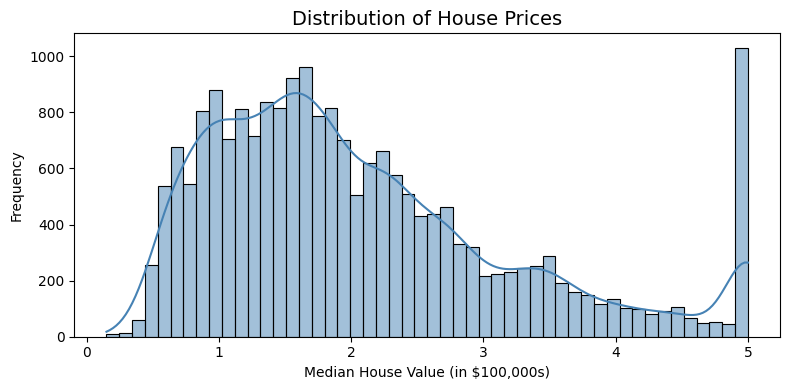

In [27]:
# Distribution of Target Variable
plt.figure(figsize=(8, 4))
sns.histplot(df['HousePrice'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

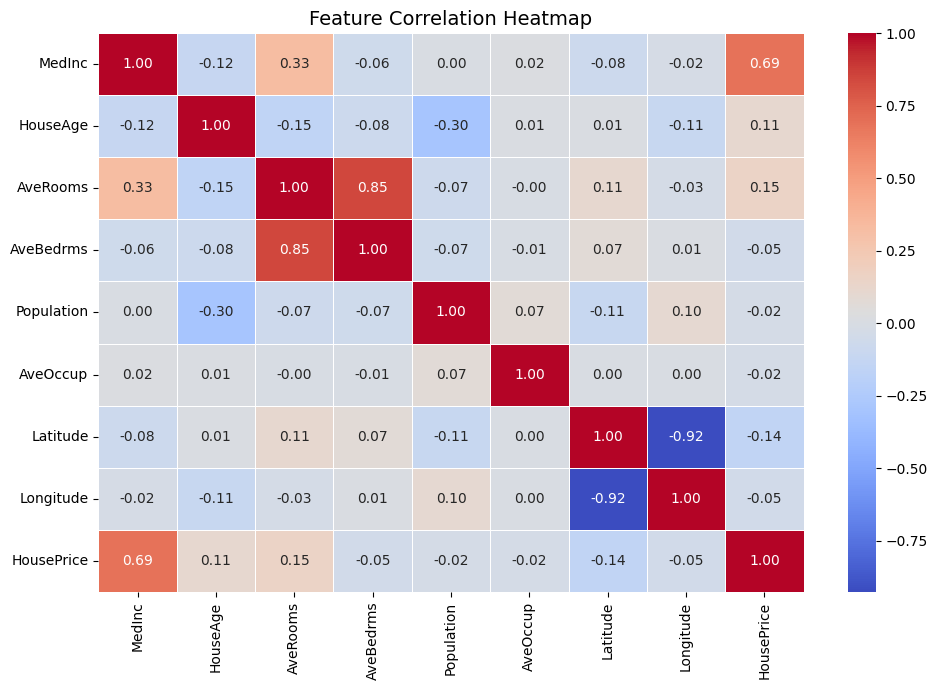


Top features correlated with HousePrice:
HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: HousePrice, dtype: float64


In [28]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTop features correlated with HousePrice:")
print(corr_matrix['HousePrice'].sort_values(ascending=False))

---
## Step 4: Separate Features and Target Variable

In [29]:
# Separate input features (X) and target variable (y)
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nInput Features:", list(X.columns))

Features (X) shape: (20640, 8)
Target (y) shape: (20640,)

Input Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## Step 5: Feature Scaling (Critical Preprocessing Step)

> **Why Feature Scaling?**  
> Features like `MedInc` and `Population` exist on very different numeric ranges.  
> Without scaling, larger-range features dominate the model, causing unstable performance.  
> `StandardScaler` converts all features to have **mean = 0** and **standard deviation = 1**.

In [30]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Before Scaling – Feature Means:")
print(X.mean().round(2))
print("\nAfter Scaling – Feature Means (should be ~0):")
print(X_scaled_df.mean().round(4))
print("\nAfter Scaling – Feature Std Dev (should be ~1):")
print(X_scaled_df.std().round(4))

Before Scaling – Feature Means:
MedInc           3.87
HouseAge        28.64
AveRooms         5.43
AveBedrms        1.10
Population    1425.48
AveOccup         3.07
Latitude        35.63
Longitude     -119.57
dtype: float64

After Scaling – Feature Means (should be ~0):
MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms    -0.0
Population   -0.0
AveOccup      0.0
Latitude     -0.0
Longitude    -0.0
dtype: float64

After Scaling – Feature Std Dev (should be ~1):
MedInc        1.0
HouseAge      1.0
AveRooms      1.0
AveBedrms     1.0
Population    1.0
AveOccup      1.0
Latitude      1.0
Longitude     1.0
dtype: float64


---
## Step 6: Train–Test Split

In [31]:
# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)
print("\nThe model will be trained on 80% data and evaluated on unseen 20% data.")

Training set size: (16512, 8)
Testing set size:  (4128, 8)

The model will be trained on 80% data and evaluated on unseen 20% data.


---
## Step 7: Train Multiple Models

| Model | Purpose |
|---|---|
| **Linear Regression** | Baseline model – assumes linear relationship |
| **Ridge Regression** | Reduces overfitting via L2 regularization |
| **Decision Tree** | Captures non-linear patterns in data |

In [3]:
import numpy as np

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    }

    print(f"✔ {name} trained successfully.")

print("\nAll models trained!")

ModuleNotFoundError: No module named 'numpy'

---
## Step 8: Model Evaluation & Comparison

> - **RMSE (Root Mean Squared Error):** Lower is better — measures average prediction error in same units as target
> - **R² Score:** Higher is better — measures how well the model explains variance in target (1.0 = perfect)

In [33]:
# Model Performance Comparison Table
import pandas as pd

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2 Score', ascending=False)

print("=" * 50)
print("       MODEL PERFORMANCE COMPARISON TABLE")
print("=" * 50)
print(results_df.to_string())
print("=" * 50)
print(f"\n✅ Best Model: {results_df['R2 Score'].idxmax()}")
print(f"   R² Score  : {results_df['R2 Score'].max()}")
print(f"   RMSE      : {results_df.loc[results_df['R2 Score'].idxmax(), 'RMSE']}")

       MODEL PERFORMANCE COMPARISON TABLE
                     RMSE  R2 Score
Decision Tree      0.7242    0.5997
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758

✅ Best Model: Decision Tree
   R² Score  : 0.5997
   RMSE      : 0.7242


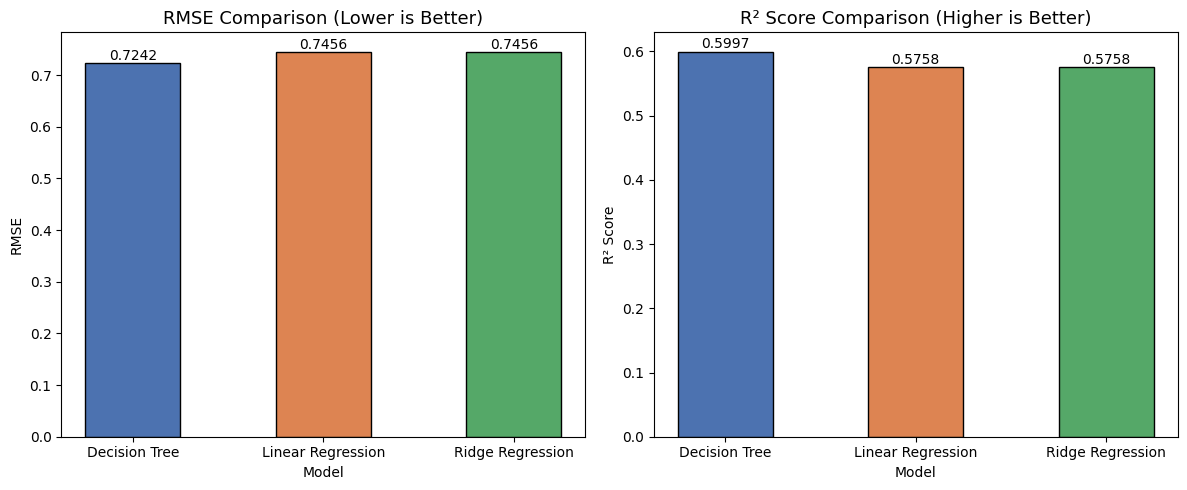

Chart saved as model_comparison_chart.png


In [34]:
# Bar Chart: RMSE Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']
model_names = list(results_df.index)

# RMSE
axes[0].bar(model_names, results_df['RMSE'], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('RMSE Comparison (Lower is Better)', fontsize=13)
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('Model')
for i, v in enumerate(results_df['RMSE']):
    axes[0].text(i, v + 0.005, str(v), ha='center', fontsize=10)

# R2 Score
axes[1].bar(model_names, results_df['R2 Score'], color=colors, edgecolor='black', width=0.5)
axes[1].set_title('R² Score Comparison (Higher is Better)', fontsize=13)
axes[1].set_ylabel('R² Score')
axes[1].set_xlabel('Model')
for i, v in enumerate(results_df['R2 Score']):
    axes[1].text(i, v + 0.005, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as model_comparison_chart.png")

---
## Step 9: Visual Performance Validation (Actual vs Predicted)

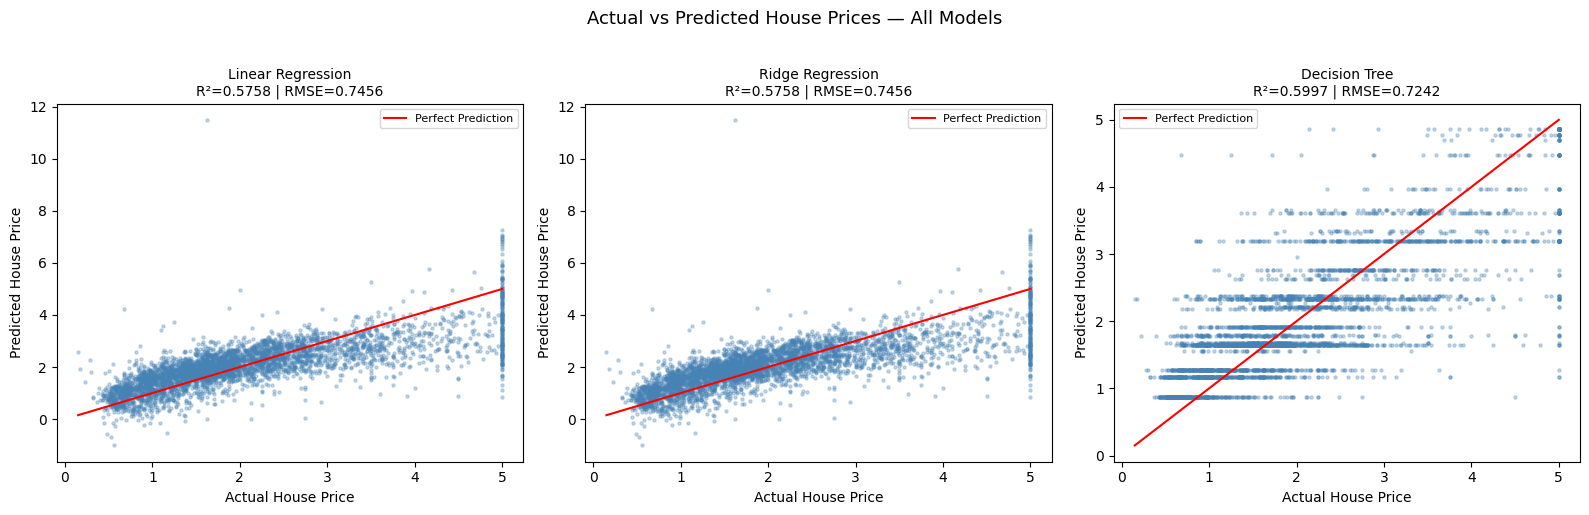

Plot saved as actual_vs_predicted.png


In [35]:
# Actual vs Predicted plots for all 3 models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color='red', linewidth=1.5, label='Perfect Prediction')
    ax.set_title(f'{name}\nR²={results[name]["R2 Score"]} | RMSE={results[name]["RMSE"]}', fontsize=10)
    ax.set_xlabel('Actual House Price')
    ax.set_ylabel('Predicted House Price')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted House Prices — All Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as actual_vs_predicted.png")

---
## Step 10: Best Model Selection & Conclusion

In [36]:
best_model_name = results_df['R2 Score'].idxmax()
best_r2 = results_df['R2 Score'].max()
best_rmse = results_df.loc[best_model_name, 'RMSE']

print("="*55)
print("          FINAL MODEL SELECTION — CONCLUSION")
print("="*55)
print(f"  Best Model  : {best_model_name}")
print(f"  R² Score    : {best_r2}  (Higher → Better)")
print(f"  RMSE        : {best_rmse}  (Lower → Better)")
print("="*55)
print()
print("Justification:")
print(f"  The {best_model_name} achieved the highest R² score ({best_r2})")
print(f"  and the lowest RMSE ({best_rmse}) among all trained models.")
print("  This indicates it explains the most variance in house prices")
print("  while producing the smallest prediction errors on unseen data.")

          FINAL MODEL SELECTION — CONCLUSION
  Best Model  : Decision Tree
  R² Score    : 0.5997  (Higher → Better)
  RMSE        : 0.7242  (Lower → Better)

Justification:
  The Decision Tree achieved the highest R² score (0.5997)
  and the lowest RMSE (0.7242) among all trained models.
  This indicates it explains the most variance in house prices
  while producing the smallest prediction errors on unseen data.


In [37]:
# Optional: Save best model using joblib
import joblib

best_model = models[best_model_name]
joblib.dump(best_model, 'best_model.pkl')
print(f"Best model ({best_model_name}) saved as 'best_model.pkl'")

# Optional: Load and test
loaded_model = joblib.load('best_model.pkl')
test_pred = loaded_model.predict(X_test[:5])
print("\nSample predictions from loaded model:", test_pred.round(4))
print("Actual values:                        ", y_test[:5].values.round(4))

Best model (Decision Tree) saved as 'best_model.pkl'

Sample predictions from loaded model: [1.1686 1.2716 3.1996 2.2048 1.6428]
Actual values:                         [0.477 0.458 5.    2.186 2.78 ]


---
## Summary

| Step | Action |
|------|--------|
| 1 | Imported all required libraries |
| 2 | Loaded California Housing Dataset |
| 3 | Explored data using EDA (histograms, heatmaps) |
| 4 | Separated features (X) and target (y) |
| 5 | Applied StandardScaler for feature scaling |
| 6 | Split data: 80% train, 20% test |
| 7 | Trained 3 models: Linear, Ridge, Decision Tree |
| 8 | Compared RMSE and R² for all models |
| 9 | Visualized Actual vs Predicted plots |
| 10 | Selected best model with justification |

> **Key Takeaway:** Real-world ML pipelines require preprocessing, model comparison, and metric-driven decisions — not just training a single model.